In [1]:
import networkx as nx
#import random
import numpy as np
import matplotlib.pyplot as plt
#import csv
#import operator
#import six
import pandas as pd
from matplotlib import colors
%matplotlib inline
from unidecode import unidecode
import geopandas as gpd
import math
import descartes

In [2]:
MatrixPath = '../data/Cross_Parker-Manufacturing_info (differentiated in terms of advice).xlsx'
attributePath = '../data/Cross_Parker-Manufacturing_ATTR.xlsx'

In [3]:
matrix = pd.read_excel(MatrixPath, header=0, index_col=0)
attribute = pd.read_excel(attributePath, header=0, index_col=0)

In [4]:
nodeNames = list(attribute.index)

In [5]:
# create a list of our conditions

conditions = [
    (attribute['location'] == 1),
    (attribute['location'] == 2),
    (attribute['location'] == 3),
    (attribute['location'] == 4)
    ]

# create a list of the values we want to assign for each condition
values = ['Paris', 'Frankfurt', ' Warsaw', 'Geneva']

attribute['city'] = np.select(conditions, values)

# Preparation for normalisation

In [6]:
import collections

In [7]:
# count the number of people in each location

Count = dict(collections.Counter(attribute.city))
#occurrences = collections.Counter(a_list)

In [8]:
Count

{'Paris': 17, 'Frankfurt': 27, ' Warsaw': 16, 'Geneva': 17}

In [9]:
# define a function to remove a key from a dict
def removekey(d, key):
    r = dict(d)
    del r[key]
    return r

In [10]:
# define a function for n choose r
def nCr(n,r):
    f = math.factorial
    return f(n) // f(r) // f(n-r)

# Normalisation denominators to be defined

In [11]:
# coordinator normalisation denominator
def normCo(node,Count):
    city = attribute.loc[node].city 
    n = Count[city]
    if n>2:
        m = nCr(n-1,2)*2
    else:
        m = 1
    return m

# gatekeeper and representative normalisation denominator
def normGaRe(node,Count):
    city = attribute.loc[node].city
    n = Count[city]
    newCount = removekey(Count,city)
    if n>1:
        m = 0
        for key in newCount:
            m += newCount[key]*(n-1)
    else:
        m = 1
    return m

# itinerant normalisation denominator
def normIt(node,Count):
    city = attribute.loc[node].city
    n = Count[city]
    newCount = removekey(Count,city)
    m = 0
    for key in newCount:
        temp = newCount[key]
        if temp > 1:
            m += nCr(temp,2)*2
    return m

# liaison normalisation denominator
def normLi(node,Count):
    city = attribute.loc[node].city
    n = Count[city]
    newCount = removekey(Count,city)
    m = 0
    for key in newCount:
        v1 = newCount[key]
        tempCount = removekey(newCount,key)
        for ind in tempCount:
            v2 = tempCount[ind]
            m += v1*v2
    return m


In [12]:
# Create a network
# Note that I have removed the self-loops. 

G = nx.DiGraph()

for i in nodeNames:
    for j in nodeNames:
        if i != j:
            G.add_edge(i,j,weight=matrix.loc[i,j])
            
for node in G.nodes:
    G.nodes[node]['city'] = attribute.loc[node].city

In [13]:
# here I define the inverse function
def inverse(n):
    if n != 0:
        return 1/n
    else:
        return 1/0.00000000000000000000000000000000000000000000000000001

In [14]:
# Now I am going to calculate the number of occurances for shortest path each type of the brokerage. 

GF = {}
for node in G.nodes:
    temp = {'coordinator':0, 'itinerant':0, 'gatekeeper':0, 'representative':0, 'liaison':0, 'total':0,
           'coPairs':[], 'itPairs':[], 'gaPairs':[], 'rePairs':[], 'liPairs':[], 'toPairs':[]}
    for up in G.predecessors(node):
        for down in G.successors(node):
            if up != down:
                w_updown = G[up][down]['weight']
                w_upn = G[up][node]['weight']
                w_ndown = G[node][down]['weight']
                if (w_updown==0 and w_upn>0 and w_ndown>0) or (w_updown>0 and w_upn>0 and w_ndown>0 and 1/w_updown>1/w_upn+1/w_ndown):
                    if G.nodes[up]['city']==G.nodes[node]['city']==G.nodes[down]['city']:
                        temp['coordinator'] += 1
                        temp['coPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']==G.nodes[down]['city']!=G.nodes[node]['city']:
                        temp['itinerant'] += 1
                        temp['itPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']!=G.nodes[down]['city']==G.nodes[node]['city']:
                        temp['gatekeeper'] += 1
                        temp['gaPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']==G.nodes[node]['city']!=G.nodes[down]['city']:
                        temp['representative'] += 1
                        temp['rePairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']!=G.nodes[node]['city']!=G.nodes[down]['city'] and G.nodes[up]['city']!=G.nodes[down]['city']:
                        temp['liaison'] += 1
                        temp['liPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
    # Note that this time all the five roles frequencies are normalised. 
    temp['coordinator'] = temp['coordinator']/normCo(node,Count)
    temp['itinerant'] = temp['itinerant']/normIt(node,Count)
    temp['gatekeeper'] = temp['gatekeeper']/normGaRe(node,Count)
    temp['representative'] = temp['representative']/normGaRe(node,Count)
    temp['liaison'] = temp['liaison']/normLi(node,Count)
    GF[node]=temp

In [14]:
# Now I am going to calculate the number of occurances for shortest path each type of the brokerage. 

GF = {}
for node in G.nodes:
    temp = {'coordinator':0, 'itinerant':0, 'gatekeeper':0, 'representative':0, 'liaison':0, 'total':0,
           'coPairs':[], 'itPairs':[], 'gaPairs':[], 'rePairs':[], 'liPairs':[], 'toPairs':[]}
    for up in G.predecessors(node):
        for down in G.successors(node):
            if up != down:
                #if weight of direct link is 0 G[up][down]['weight'] == 0
                if G[up][down]['weight'] == 0 or inverse(G[up][node]['weight']) + inverse(G[node][down]['weight'])< inverse(G[up][down]['weight']):
                #if min(G[up][node]['weight'],G[node][down]['weight'])>G[up][down]['weight']:
                    if G.nodes[up]['city']==G.nodes[node]['city']==G.nodes[down]['city']:
                        temp['coordinator'] += 1
                        temp['coPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']==G.nodes[down]['city']!=G.nodes[node]['city']:
                        temp['itinerant'] += 1
                        temp['itPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']!=G.nodes[down]['city']==G.nodes[node]['city']:
                        temp['gatekeeper'] += 1
                        temp['gaPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']==G.nodes[node]['city']!=G.nodes[down]['city']:
                        temp['representative'] += 1
                        temp['rePairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif G.nodes[up]['city']!=G.nodes[node]['city']!=G.nodes[down]['city'] and G.nodes[up]['city']!=G.nodes[down]['city']:
                        temp['liaison'] += 1
                        temp['liPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])

    
    # Note that this time all the five roles frequencies are normalised. 
    temp['coordinator'] = temp['coordinator']/normCo(node,Count)
    temp['itinerant'] = temp['itinerant']/normIt(node,Count)
    temp['gatekeeper'] = temp['gatekeeper']/normGaRe(node,Count)
    temp['representative'] = temp['representative']/normGaRe(node,Count)
    temp['liaison'] = temp['liaison']/normLi(node,Count)
    GF[node]=temp


In [15]:
# Now I reorganise the results

coRank = []
itRank = []
gaRank = []
reRank = []
liRank = []
toRank = []
for node in nodeNames:
    coRank.append({'node':node, 'coordinator':GF[node]['coordinator']})
    itRank.append({'node':node, 'itinerant':GF[node]['itinerant']})
    gaRank.append({'node':node, 'gatekeeper':GF[node]['gatekeeper']})
    reRank.append({'node':node, 'representative':GF[node]['representative']})
    liRank.append({'node':node, 'liaison':GF[node]['liaison']})
    toRank.append({'node':node, 'total':GF[node]['total']})


In [42]:
# Turn them into DataFrame

coRankDF = pd.DataFrame(coRank)
itRankDF = pd.DataFrame(itRank)
gaRankDF = pd.DataFrame(gaRank)
reRankDF = pd.DataFrame(reRank)
liRankDF = pd.DataFrame(liRank)
toRankDF = pd.DataFrame(toRank)
gf_freq = pd.concat([coRankDF, itRankDF.itinerant, gaRankDF.gatekeeper, reRankDF.representative,
           liRankDF.liaison, toRankDF.total], axis=1, sort=False)
#gf_freq.to_csv('../tables/freq_manufact_company_corr.csv')

In [17]:
gf_freq.sort_values(by='liaison', ascending=True)

,node,coordinator,itinerant,gatekeeper,representative,liaison,total
0,1,0.020833,0.000000,0.000000,0.000000,0.000000,5
31,32,0.138462,0.000000,0.006923,0.000000,0.000000,99
32,33,0.029231,0.000000,0.005385,0.000000,0.000000,26
75,76,0.012500,0.000000,0.000000,0.000000,0.000000,3
41,42,0.049231,0.000000,0.035385,0.029231,0.000000,116
...,...,...,...,...,...,...,...
28,29,0.370769,0.005102,0.238462,0.286154,0.067227,1039
17,18,0.110769,0.000000,0.230769,0.382308,0.069628,985
12,13,0.304167,0.009885,0.441667,0.488542,0.216251,1481
14,15,0.283333,0.003295,0.334375,0.885417,0.291058,1920


In [18]:
gf_freq.sort_values(by='liaison', ascending=True)

,node,coordinator,itinerant,gatekeeper,representative,liaison,total
56,57,0.138095,0.054575,0.810929,0.830601,0.801574,3534
58,59,0.033333,0.054575,0.809836,0.825137,0.801574,3506
52,53,0.100000,0.054575,0.805464,0.825137,0.801574,3516
51,52,0.180952,0.054575,0.816393,0.834973,0.801574,3552
57,58,0.319048,0.054575,0.825137,0.831694,0.801574,3586
...,...,...,...,...,...,...,...
13,14,0.100000,0.046952,0.822917,0.819792,0.819862,3565
28,29,0.370769,0.096939,0.886154,0.852308,0.819928,3943
14,15,0.283333,0.046952,0.864583,0.885417,0.822012,3717
12,13,0.304167,0.054366,0.911458,0.898958,0.844798,3842


# Dichotomization

## Threshold

In [18]:
# create a network where there is no edge weight 0, instead the edge is missing
matrix_np = matrix.to_numpy()
G2 = nx.from_numpy_matrix(matrix_np, create_using=nx.DiGraph)
mapping = dict(zip(G2, attribute.index))
G2 = nx.relabel_nodes(G2, mapping)  

In [19]:
# what are the bottom 10% of edges
from itertools import groupby
weight_value = list(nx.get_edge_attributes(G2,'weight').values())
sort_weight = sorted(weight_value)
len(sort_weight)*0.10
sort_weight[222]

1

In [20]:
len(sort_weight)*0.10

222.8

In [21]:
def numberlist(nums, limit):
    prefix = []
    sum = 0
    for num in nums:
        sum += num
        prefix.append(num)
        if sum > limit:
            return prefix

In [22]:
def slice_network(G, T, data = True):
    """ Remove all edges with weight<T from G or its copy. """
    F = G.copy()
    F.remove_edges_from([(n1, n2) for n1, n2, w in F.edges(data="weight") if w < T])
    return F

In [23]:
#slice_network(G_m, 33.64)
print(nx.info(slice_network(G, 2)))

Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 1452
Average in degree:  18.8571
Average out degree:  18.8571


In [24]:
F_m = G.copy()
F_m.remove_edges_from([(n1, n2) for n1, n2, w in F_m.edges(data="weight") if w < 2])
print(nx.info(F_m))

Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 1452
Average in degree:  18.8571
Average out degree:  18.8571


In [25]:
print(nx.info(G2))

Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 2228
Average in degree:  28.9351
Average out degree:  28.9351


In [68]:
(2228-1452)/2228

0.348294434470377

In [26]:
#create edges with a weight of 0 if edge is missing
for i in nodeNames:
    for j in nodeNames:
        if i != j:
            if F_m.has_edge(i,j) == False:
                F_m.add_edge(i,j,weight= 0)

In [27]:
# Calculate original Gould-Fernandez measure 

GF_F_m = {}
for node in F_m.nodes:
    temp = {'coordinator':0, 'itinerant':0, 'gatekeeper':0, 'representative':0, 'liaison':0, 'total':0,
           'coPairs':[], 'itPairs':[], 'gaPairs':[], 'rePairs':[], 'liPairs':[], 'toPairs':[]}
    for up in F_m.predecessors(node):
        for down in F_m.successors(node):
            if up != down:
                if min(F_m[up][node]['weight'],F_m[node][down]['weight'])>F_m[up][down]['weight']:
                    if F_m.nodes[up]['city']==F_m.nodes[down]['city']==F_m.nodes[node]['city']:
                        temp['coordinator'] += 1
                        temp['coPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif F_m.nodes[up]['city']==F_m.nodes[down]['city']!=F_m.nodes[node]['city']:
                        temp['itinerant'] += 1
                        temp['itPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif F_m.nodes[up]['city']!=F_m.nodes[down]['city']==F_m.nodes[node]['city']:
                        temp['gatekeeper'] += 1
                        temp['gaPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif F_m.nodes[up]['city']==F_m.nodes[node]['city']!=F_m.nodes[down]['city']:
                        temp['representative'] += 1
                        temp['rePairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif F_m.nodes[up]['city']!=F_m.nodes[node]['city']!=F_m.nodes[down]['city'] and F_m.nodes[up]['city']!=F_m.nodes[down]['city']:
                        temp['liaison'] += 1
                        temp['liPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
    
    # Note that this time all the five roles frequencies are normalised. 
    temp['coordinator'] = temp['coordinator']/normCo(node,Count)
    temp['itinerant'] = temp['itinerant']/normIt(node,Count)
    temp['gatekeeper'] = temp['gatekeeper']/normGaRe(node,Count)
    temp['representative'] = temp['representative']/normGaRe(node,Count)
    temp['liaison'] = temp['liaison']/normLi(node,Count)
    GF_F_m[node]=temp


In [43]:
# Now I reorganise the results

coRank_th = []
itRank_th = []
gaRank_th = []
reRank_th = []
liRank_th = []
toRank_th = []
for node in nodeNames:
    coRank_th.append({'node':node, 'coordinator':GF_F_m[node]['coordinator']})
    itRank_th.append({'node':node, 'itinerant':GF_F_m[node]['itinerant']})
    gaRank_th.append({'node':node, 'gatekeeper':GF_F_m[node]['gatekeeper']})
    reRank_th.append({'node':node, 'representative':GF_F_m[node]['representative']})
    liRank_th.append({'node':node, 'liaison':GF_F_m[node]['liaison']})
    toRank_th.append({'node':node, 'total':GF_F_m[node]['total']})
    
# Turn them into DataFrame

coRankDF_th = pd.DataFrame(coRank_th)
itRankDF_th = pd.DataFrame(itRank_th)
gaRankDF_th = pd.DataFrame(gaRank_th)
reRankDF_th = pd.DataFrame(reRank_th)
liRankDF_th = pd.DataFrame(liRank_th)
toRankDF_th = pd.DataFrame(toRank_th)
gf_freq_th = pd.concat([coRankDF_th, itRankDF_th.itinerant, gaRankDF_th.gatekeeper, reRankDF_th.representative,
           liRankDF_th.liaison, toRankDF_th.total], axis=1, sort=False)
#gf_freq_th.to_csv('../tables/freq_manufact_company_thresh.csv')

In [49]:
# coordinator values are not normalized between 0 - 1 
gf_freq_th.sort_values(by='coordinator', ascending=False)

,node,coordinator,itinerant,gatekeeper,representative,liaison,total
67,68,0.675000,0.063427,0.483333,0.537500,0.266122,1838
28,29,0.670769,0.003827,0.126154,0.209231,0.023409,914
55,56,0.638095,0.000000,0.120219,0.059016,0.001243,301
12,13,0.533333,0.019769,0.325000,0.330208,0.105331,1026
54,55,0.461905,0.003210,0.158470,0.177049,0.019056,454
...,...,...,...,...,...,...,...
45,46,0.019048,0.000000,0.004372,0.000000,0.000000,8
9,10,0.016667,0.000000,0.021875,0.033333,0.000000,57
60,61,0.004167,0.000824,0.052083,0.019792,0.000000,71
69,70,0.004167,0.000000,0.010417,0.000000,0.000000,11


In [44]:
from scipy.stats import pearsonr

In [56]:
print(pearsonr(gf_freq.coordinator, gf_freq_b.coordinator))
print(pearsonr(gf_freq.liaison, gf_freq_b.liaison))
print(pearsonr(gf_freq.itinerant, gf_freq_b.itinerant))
print(pearsonr(gf_freq.gatekeeper, gf_freq_b.gatekeeper))
print(pearsonr(gf_freq.representative, gf_freq_b.representative))

(0.9305639156940876, 1.8448006989720404e-34)
(0.8912853067282914, 1.7811293228889366e-27)
(0.9139551776389775, 4.222315743957551e-31)
(0.8537033840943916, 5.989282037932071e-23)
(0.5974181048388088, 9.711225652126976e-09)


In [60]:
from scipy.stats import spearmanr
# seed random number generator
# calculate spearman's correlation
coef, p = spearmanr(gf_freq.coordinator, gf_freq_b.coordinator)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.liaison, gf_freq_b.liaison)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    

coef, p = spearmanr(gf_freq.itinerant, gf_freq_b.itinerant)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.gatekeeper, gf_freq_b.gatekeeper)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.representative, gf_freq_b.representative)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)

Spearmans correlation coefficient: 0.911
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.684
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.726
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.771
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.761
Samples are correlated (reject H0) p=0.000


In [59]:
from scipy.stats import spearmanr
# seed random number generator
# calculate spearman's correlation
coef, p = spearmanr(gf_freq.coordinator, gf_freq_th.coordinator)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.liaison, gf_freq_th.liaison)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    

coef, p = spearmanr(gf_freq.itinerant, gf_freq_th.itinerant)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.gatekeeper, gf_freq_th.gatekeeper)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)
    
coef, p = spearmanr(gf_freq.representative, gf_freq_th.representative)
print('Spearmans correlation coefficient: %.3f' % coef)
# interpret the significance
alpha = 0.05
if p > alpha:
    print('Samples are uncorrelated (fail to reject H0) p=%.3f' % p)
else:
    print('Samples are correlated (reject H0) p=%.3f' % p)

Spearmans correlation coefficient: 0.956
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.807
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.888
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.909
Samples are correlated (reject H0) p=0.000
Spearmans correlation coefficient: 0.796
Samples are correlated (reject H0) p=0.000


(0.9611125399279252, 1.1652703509183996e-43)


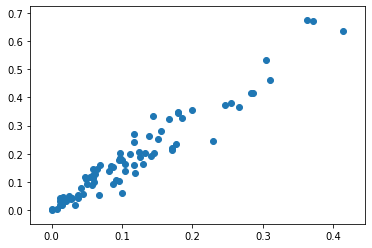

In [45]:
print(pearsonr(gf_freq.coordinator, gf_freq_th.coordinator))
plt.scatter(gf_freq.coordinator, gf_freq_th.coordinator)

(0.9179818460508533, 7.540046977117196e-32)


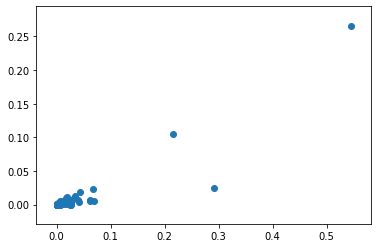

In [46]:
print(pearsonr(gf_freq.liaison, gf_freq_th.liaison))
plt.scatter(gf_freq.liaison, gf_freq_th.liaison)

(0.9759685330516755, 2.2093105214079476e-51)


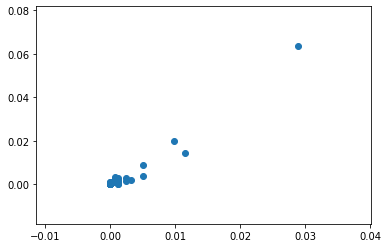

In [47]:
print(pearsonr(gf_freq.itinerant, gf_freq_th.itinerant))
plt.scatter(gf_freq.itinerant, gf_freq_th.itinerant)

(0.9336273043131192, 3.5937275824645254e-35)


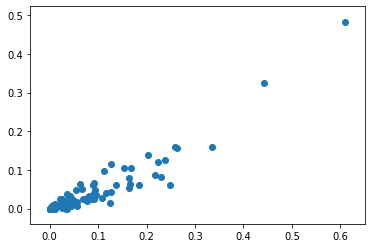

In [48]:
print(pearsonr(gf_freq.gatekeeper, gf_freq_th.gatekeeper))
plt.scatter(gf_freq.gatekeeper, gf_freq_th.gatekeeper)

(0.6352589752647548, 5.44440204149749e-10)


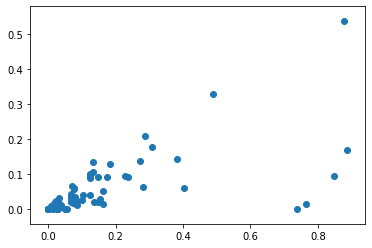

In [49]:
print(pearsonr(gf_freq.representative, gf_freq_th.representative))
plt.scatter(gf_freq.representative, gf_freq_th.representative)

(0.5974181048388088, 9.711225652126976e-09)


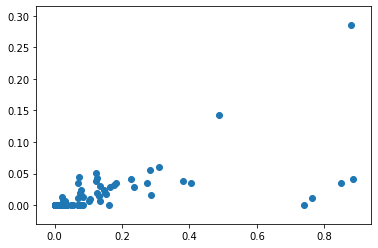

In [57]:
print(pearsonr(gf_freq.representative, gf_freq_b.representative))
plt.scatter(gf_freq.representative, gf_freq_b.representative)

In [51]:
differences = pd.DataFrame(list(zip(abs(gf_freq_th.coordinator - gf_freq.coordinator), abs(gf_freq_th.itinerant - gf_freq.itinerant),
                                   abs(gf_freq_th.gatekeeper - gf_freq.gatekeeper), abs(gf_freq_th.representative - gf_freq.representative),
                                   abs(gf_freq_th.liaison - gf_freq.liaison), abs(gf_freq_th.total - gf_freq.total))),
               columns =['coordinator', 'itinerant', 'gatekeeper', 'representative', 'liaison', 'total'],
                          index=gf_freq.index)

In [70]:
differences_b = pd.DataFrame(list(zip(abs(gf_freq_b.coordinator - gf_freq.coordinator), abs(gf_freq_b.itinerant - gf_freq.itinerant),
                                   abs(gf_freq_b.gatekeeper - gf_freq.gatekeeper), abs(gf_freq_b.representative - gf_freq.representative),
                                   abs(gf_freq_b.liaison - gf_freq.liaison), abs(gf_freq_b.total - gf_freq.total))),
               columns =['coordinator', 'itinerant', 'gatekeeper', 'representative', 'liaison', 'total'],
                          index=gf_freq.index)

In [78]:
differences_b.sort_values(by='liaison', ascending=False).head(15)

#rep: 14,27,48,73,67
#coord: 28, 67,37,55,14
#itin: 40,28,12,30,14,8
#gate:67,12,14,53,22
#lia: 67,14,12,17,28

,coordinator,itinerant,gatekeeper,representative,liaison,total
67,0.200000,0.001647,0.417708,0.592708,0.481943,2041
14,0.091667,0.002471,0.284375,0.843750,0.288908,1736
12,0.016667,0.004942,0.332292,0.345833,0.189166,1093
17,0.041538,0.000000,0.205385,0.343846,0.069028,802
28,0.224615,0.005102,0.165385,0.270769,0.066627,536
22,0.080000,0.000000,0.235385,0.226154,0.060624,649
27,0.020000,0.001276,0.036923,0.813077,0.060024,1193
53,0.009524,0.000803,0.239344,0.368306,0.041011,654
54,0.047619,0.001605,0.190164,0.246995,0.040597,486
70,0.054167,0.000000,0.142708,0.143750,0.040413,356


In [84]:
G2.edges(12, data=True)

OutEdgeDataView([(12, 1, {'weight': 5}), (12, 2, {'weight': 5}), (12, 3, {'weight': 3}), (12, 4, {'weight': 3}), (12, 5, {'weight': 3}), (12, 6, {'weight': 3}), (12, 7, {'weight': 3}), (12, 8, {'weight': 1}), (12, 9, {'weight': 5}), (12, 10, {'weight': 1}), (12, 11, {'weight': 1}), (12, 13, {'weight': 6}), (12, 14, {'weight': 1}), (12, 15, {'weight': 6}), (12, 16, {'weight': 2}), (12, 17, {'weight': 5}), (12, 35, {'weight': 1}), (12, 47, {'weight': 1}), (12, 52, {'weight': 1}), (12, 68, {'weight': 1}), (12, 71, {'weight': 1})])

In [79]:
differences.sort_values(by='liaison', ascending=False).head(15)

#rep: 27,48,73,14,53,67
#coord:67,28,12,55,22,2
#itin: 67,12,30,40,54,14
#gate: 53,14,17,10,67
# liai:67,14,12,17,27

27:1, 48:1, 14:4, 67:6, 12:3, 17:2

,coordinator,itinerant,gatekeeper,representative,liaison,total
67,0.312500,0.034596,0.127083,0.340625,0.279450,982
14,0.133333,0.001647,0.175000,0.716667,0.266122,1445
12,0.229167,0.009885,0.116667,0.158333,0.110920,455
17,0.089231,0.000000,0.148462,0.237692,0.064226,551
27,0.143077,0.001276,0.006923,0.753846,0.057023,992
22,0.190769,0.000000,0.105385,0.218462,0.055822,390
28,0.300000,0.001276,0.112308,0.076923,0.043818,125
53,0.033333,0.000000,0.186885,0.344262,0.037283,569
70,0.079167,0.000000,0.103125,0.084375,0.033104,238
73,0.066667,0.000000,0.002083,0.738542,0.027085,758


### Backbone

In [29]:
from scipy import integrate

In [30]:
def disparity_filter(G, weight='weight'):
    ''' Compute significance scores (alpha) for weighted edges in G as defined in Serrano et al. 2009
        Args
            G: Weighted NetworkX graph
        Returns
            Weighted graph with a significance score (alpha) assigned to each edge
        References
            M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''
    
    if nx.is_directed(G): #directed case    
        N = nx.DiGraph()
        for u in G:
            
            k_out = G.out_degree(u)
            k_in = G.in_degree(u)
            
            if k_out > 1:
                sum_w_out = sum(np.absolute(G[u][v][weight]) for v in G.successors(u))
                for v in G.successors(u):
                    w = G[u][v][weight]
                    p_ij_out = float(np.absolute(w))/sum_w_out
                    alpha_ij_out = 1 - (k_out-1) * integrate.quad(lambda x: (1-x)**(k_out-2), 0, p_ij_out)[0]
                    N.add_edge(u, v, weight = w, alpha_out=float('%.4f' % alpha_ij_out))
                    
            elif k_out == 1 and G.in_degree(G.successors(u)[0]) == 1:
                #we need to keep the connection as it is the only way to maintain the connectivity of the network
                v = G.successors(u)[0]
                w = G[u][v][weight]
                N.add_edge(u, v, weight = w, alpha_out=0., alpha_in=0.)
                #there is no need to do the same for the k_in, since the link is built already from the tail
            
            if k_in > 1:
                sum_w_in = sum(np.absolute(G[v][u][weight]) for v in G.predecessors(u))
                for v in G.predecessors(u):
                    w = G[v][u][weight]
                    p_ij_in = float(np.absolute(w))/sum_w_in
                    alpha_ij_in = 1 - (k_in-1) * integrate.quad(lambda x: (1-x)**(k_in-2), 0, p_ij_in)[0]
                    N.add_edge(v, u, weight = w, alpha_in=float('%.4f' % alpha_ij_in))
        return N
    
    else: #undirected case
        B = nx.Graph()
        for u in G:
            k = len(G[u])
            if k > 1:
                sum_w = sum(np.absolute(G[u][v][weight]) for v in G[u])
                for v in G[u]:
                    w = G[u][v][weight]
                    p_ij = float(np.absolute(w))/sum_w
                    alpha_ij = 1 - (k-1) * integrate.quad(lambda x: (1-x)**(k-2), 0, p_ij)[0]
                    B.add_edge(u, v, weight = w, alpha=float('%.4f' % alpha_ij))
        return B

In [31]:
def disparity_filter_alpha_cut(G,weight='weight',alpha_t=0.4, cut_mode='or'):
    ''' Performs a cut of the graph previously filtered through the disparity_filter function.
        
        Args
        ----
        G: Weighted NetworkX graph
        
        weight: string (default='weight')
            Key for edge data used as the edge weight w_ij.
            
        alpha_t: double (default='0.4')
            The threshold for the alpha parameter that is used to select the surviving edges.
            It has to be a number between 0 and 1.
            
        cut_mode: string (default='or')
            Possible strings: 'or', 'and'.
            It works only for directed graphs. It represents the logic operation to filter out edges
            that do not pass the threshold value, combining the alpha_in and alpha_out attributes
            resulting from the disparity_filter function.
            
            
        Returns
        -------
        B: Weighted NetworkX graph
            The resulting graph contains only edges that survived from the filtering with the alpha_t threshold
    
        References
        ---------
        .. M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''    
    
    
    if nx.is_directed(G):#Directed case:   
        B = nx.DiGraph()
        for u, v, w in G.edges(data=True):
            try:
                alpha_in =  w['alpha_in']
            except KeyError: #there is no alpha_in, so we assign 1. It will never pass the cut
                alpha_in = 1
            try:
                alpha_out =  w['alpha_out']
            except KeyError: #there is no alpha_out, so we assign 1. It will never pass the cut
                alpha_out = 1  
            
            if cut_mode == 'or':
                if alpha_in<alpha_t or alpha_out<alpha_t:
                    B.add_edge(u,v, weight=w[weight])
            elif cut_mode == 'and':
                if alpha_in<alpha_t and alpha_out<alpha_t:
                    B.add_edge(u,v, weight=w[weight])
        return B

    else:
        B = nx.Graph()#Undirected case:   
        for u, v, w in G.edges(data=True):
            
            try:
                alpha = w['alpha']
            except KeyError: #there is no alpha, so we assign 1. It will never pass the cut
                alpha = 1
                
            if alpha<alpha_t:
                B.add_edge(u,v, weight=w[weight])
        return B

In [53]:
print (nx.info(G_filt))

NameError: name 'G_filt' is not defined

In [32]:
G_filt = disparity_filter(G2, weight='weight')

B_b = disparity_filter_alpha_cut(G_filt, weight='weight', alpha_t=0.4, cut_mode='and')

# extract the weights of the edges into a list
all_weights = []
for (node1,node2,data) in B_b.edges(data=True):
        all_weights.append(data['weight'])
        
# sum up elements of list to get total weight
        
total = 0
# Iterate each element in list 
# and add them in variale total 
for ele in range(0, len(all_weights)): 
    total = total + all_weights[ele] 
  
# printing total value 
print("Sum of all elements in given list: ", total) 

# printing % of full weight 
#print("% of full weights: ", total / total_full) 

print (nx.info(G2))
print (nx.info(B_b))

Sum of all elements in given list:  4222
Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 2228
Average in degree:  28.9351
Average out degree:  28.9351
Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 952
Average in degree:  12.3636
Average out degree:  12.3636


In [33]:
B_b    
for node in B_b.nodes:
    B_b.nodes[node]['city'] = attribute.loc[node].city

In [34]:
for i in attribute.index:
    for j in attribute.index:
        if i != j:
            if B_b.has_edge(i,j) == False:
                B_b.add_edge(i,j,weight= 0)

In [35]:
# Calculate original GF measure 

GF_B_b = {}
for node in B_b.nodes:
    temp = {'coordinator':0, 'itinerant':0, 'gatekeeper':0, 'representative':0, 'liaison':0, 'total':0,
           'coPairs':[], 'itPairs':[], 'gaPairs':[], 'rePairs':[], 'liPairs':[], 'toPairs':[]}
    for up in B_b.predecessors(node):
        for down in B_b.successors(node):
            if up != down:
                if min(B_b[up][node]['weight'],B_b[node][down]['weight'])>B_b[up][down]['weight']:
                    if B_b.nodes[up]['city']==B_b.nodes[down]['city']==B_b.nodes[node]['city']:
                        temp['coordinator'] += 1
                        temp['coPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif B_b.nodes[up]['city']==B_b.nodes[down]['city']!=B_b.nodes[node]['city']:
                        temp['itinerant'] += 1
                        temp['itPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif B_b.nodes[up]['city']!=B_b.nodes[down]['city']==B_b.nodes[node]['city']:
                        temp['gatekeeper'] += 1
                        temp['gaPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif B_b.nodes[up]['city']==B_b.nodes[node]['city']!=B_b.nodes[down]['city']:
                        temp['representative'] += 1
                        temp['rePairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
                    elif B_b.nodes[up]['city']!=B_b.nodes[node]['city']!=B_b.nodes[down]['city'] and B_b.nodes[up]['city']!=B_b.nodes[down]['city']:
                        temp['liaison'] += 1
                        temp['liPairs'].append([up,down])
                        temp['total'] += 1
                        temp['toPairs'].append([up,down])
    
    # Note that this time all the five roles frequencies are normalised. 
    temp['coordinator'] = temp['coordinator']/normCo(node,Count)
    temp['itinerant'] = temp['itinerant']/normIt(node,Count)
    temp['gatekeeper'] = temp['gatekeeper']/normGaRe(node,Count)
    temp['representative'] = temp['representative']/normGaRe(node,Count)
    temp['liaison'] = temp['liaison']/normLi(node,Count)
    GF_B_b[node]=temp


In [36]:
# Now I reorganise the results

coRank_b = []
itRank_b = []
gaRank_b = []
reRank_b = []
liRank_b = []
toRank_b = []
for node in nodeNames:
    coRank_b.append({'node':node, 'coordinator':GF_B_b[node]['coordinator']})
    itRank_b.append({'node':node, 'itinerant':GF_B_b[node]['itinerant']})
    gaRank_b.append({'node':node, 'gatekeeper':GF_B_b[node]['gatekeeper']})
    reRank_b.append({'node':node, 'representative':GF_B_b[node]['representative']})
    liRank_b.append({'node':node, 'liaison':GF_B_b[node]['liaison']})
    toRank_b.append({'node':node, 'total':GF_B_b[node]['total']})
    
# Turn them into DataFrame

coRankDF_b = pd.DataFrame(coRank_b)
itRankDF_b = pd.DataFrame(itRank_b)
gaRankDF_b = pd.DataFrame(gaRank_b)
reRankDF_b = pd.DataFrame(reRank_b)
liRankDF_b = pd.DataFrame(liRank_b)
toRankDF_b = pd.DataFrame(toRank_b)
gf_freq_b = pd.concat([coRankDF_b, itRankDF_b.itinerant, gaRankDF_b.gatekeeper, reRankDF_b.representative,
           liRankDF_b.liaison, toRankDF_b.total], axis=1, sort=False)


In [150]:
#gf_freq_b.to_csv('../tables/freq_manufact_company_backb.csv')

### ECDF plot

In [37]:
import seaborn as sns # plotting
#import dc_stat_think as dcst # ecdf estimation
from dc_stat_think.no_numba import ecdf

In [38]:
itinerant = gf_freq.itinerant
itinerant10 = gf_freq_th.itinerant
itinerantb = gf_freq_b.itinerant

coordinator = gf_freq.coordinator
coordinator10 = gf_freq_th.coordinator
coordinatorb = gf_freq_b.coordinator

gatekeeper = gf_freq.gatekeeper
gatekeeper10 = gf_freq_th.gatekeeper
gatekeeperb = gf_freq_b.gatekeeper

representative = gf_freq.representative
representative10 = gf_freq_th.representative
representativeb = gf_freq_b.representative

liaison = gf_freq.liaison
liaison10 = gf_freq_th.liaison
liaisonb = gf_freq_b.liaison

In [39]:
# generate x and y values for ecdf

# Generate x and y values for ECDF: x, y
x_itin, y_itin = ecdf(itinerant)
x_itin10, y_itin10 = ecdf(itinerant10)
x_itinb, y_itinb = ecdf(itinerantb)

x_coord, y_coord = ecdf(coordinator)
x_coord10, y_coord10 = ecdf(coordinator10)
x_coordb, y_coordb = ecdf(coordinatorb)

x_gate, y_gate = ecdf(gatekeeper)
x_gate10, y_gate10 = ecdf(gatekeeper10)
x_gateb, y_gateb = ecdf(gatekeeperb)

x_rep, y_rep = ecdf(representative)
x_rep10, y_rep10 = ecdf(representative10)
x_repb, y_repb = ecdf(representativeb)

x_liais, y_liais = ecdf(liaison)
x_liais10, y_liais10 = ecdf(liaison10)
x_liaisb, y_liaisb = ecdf(liaisonb)

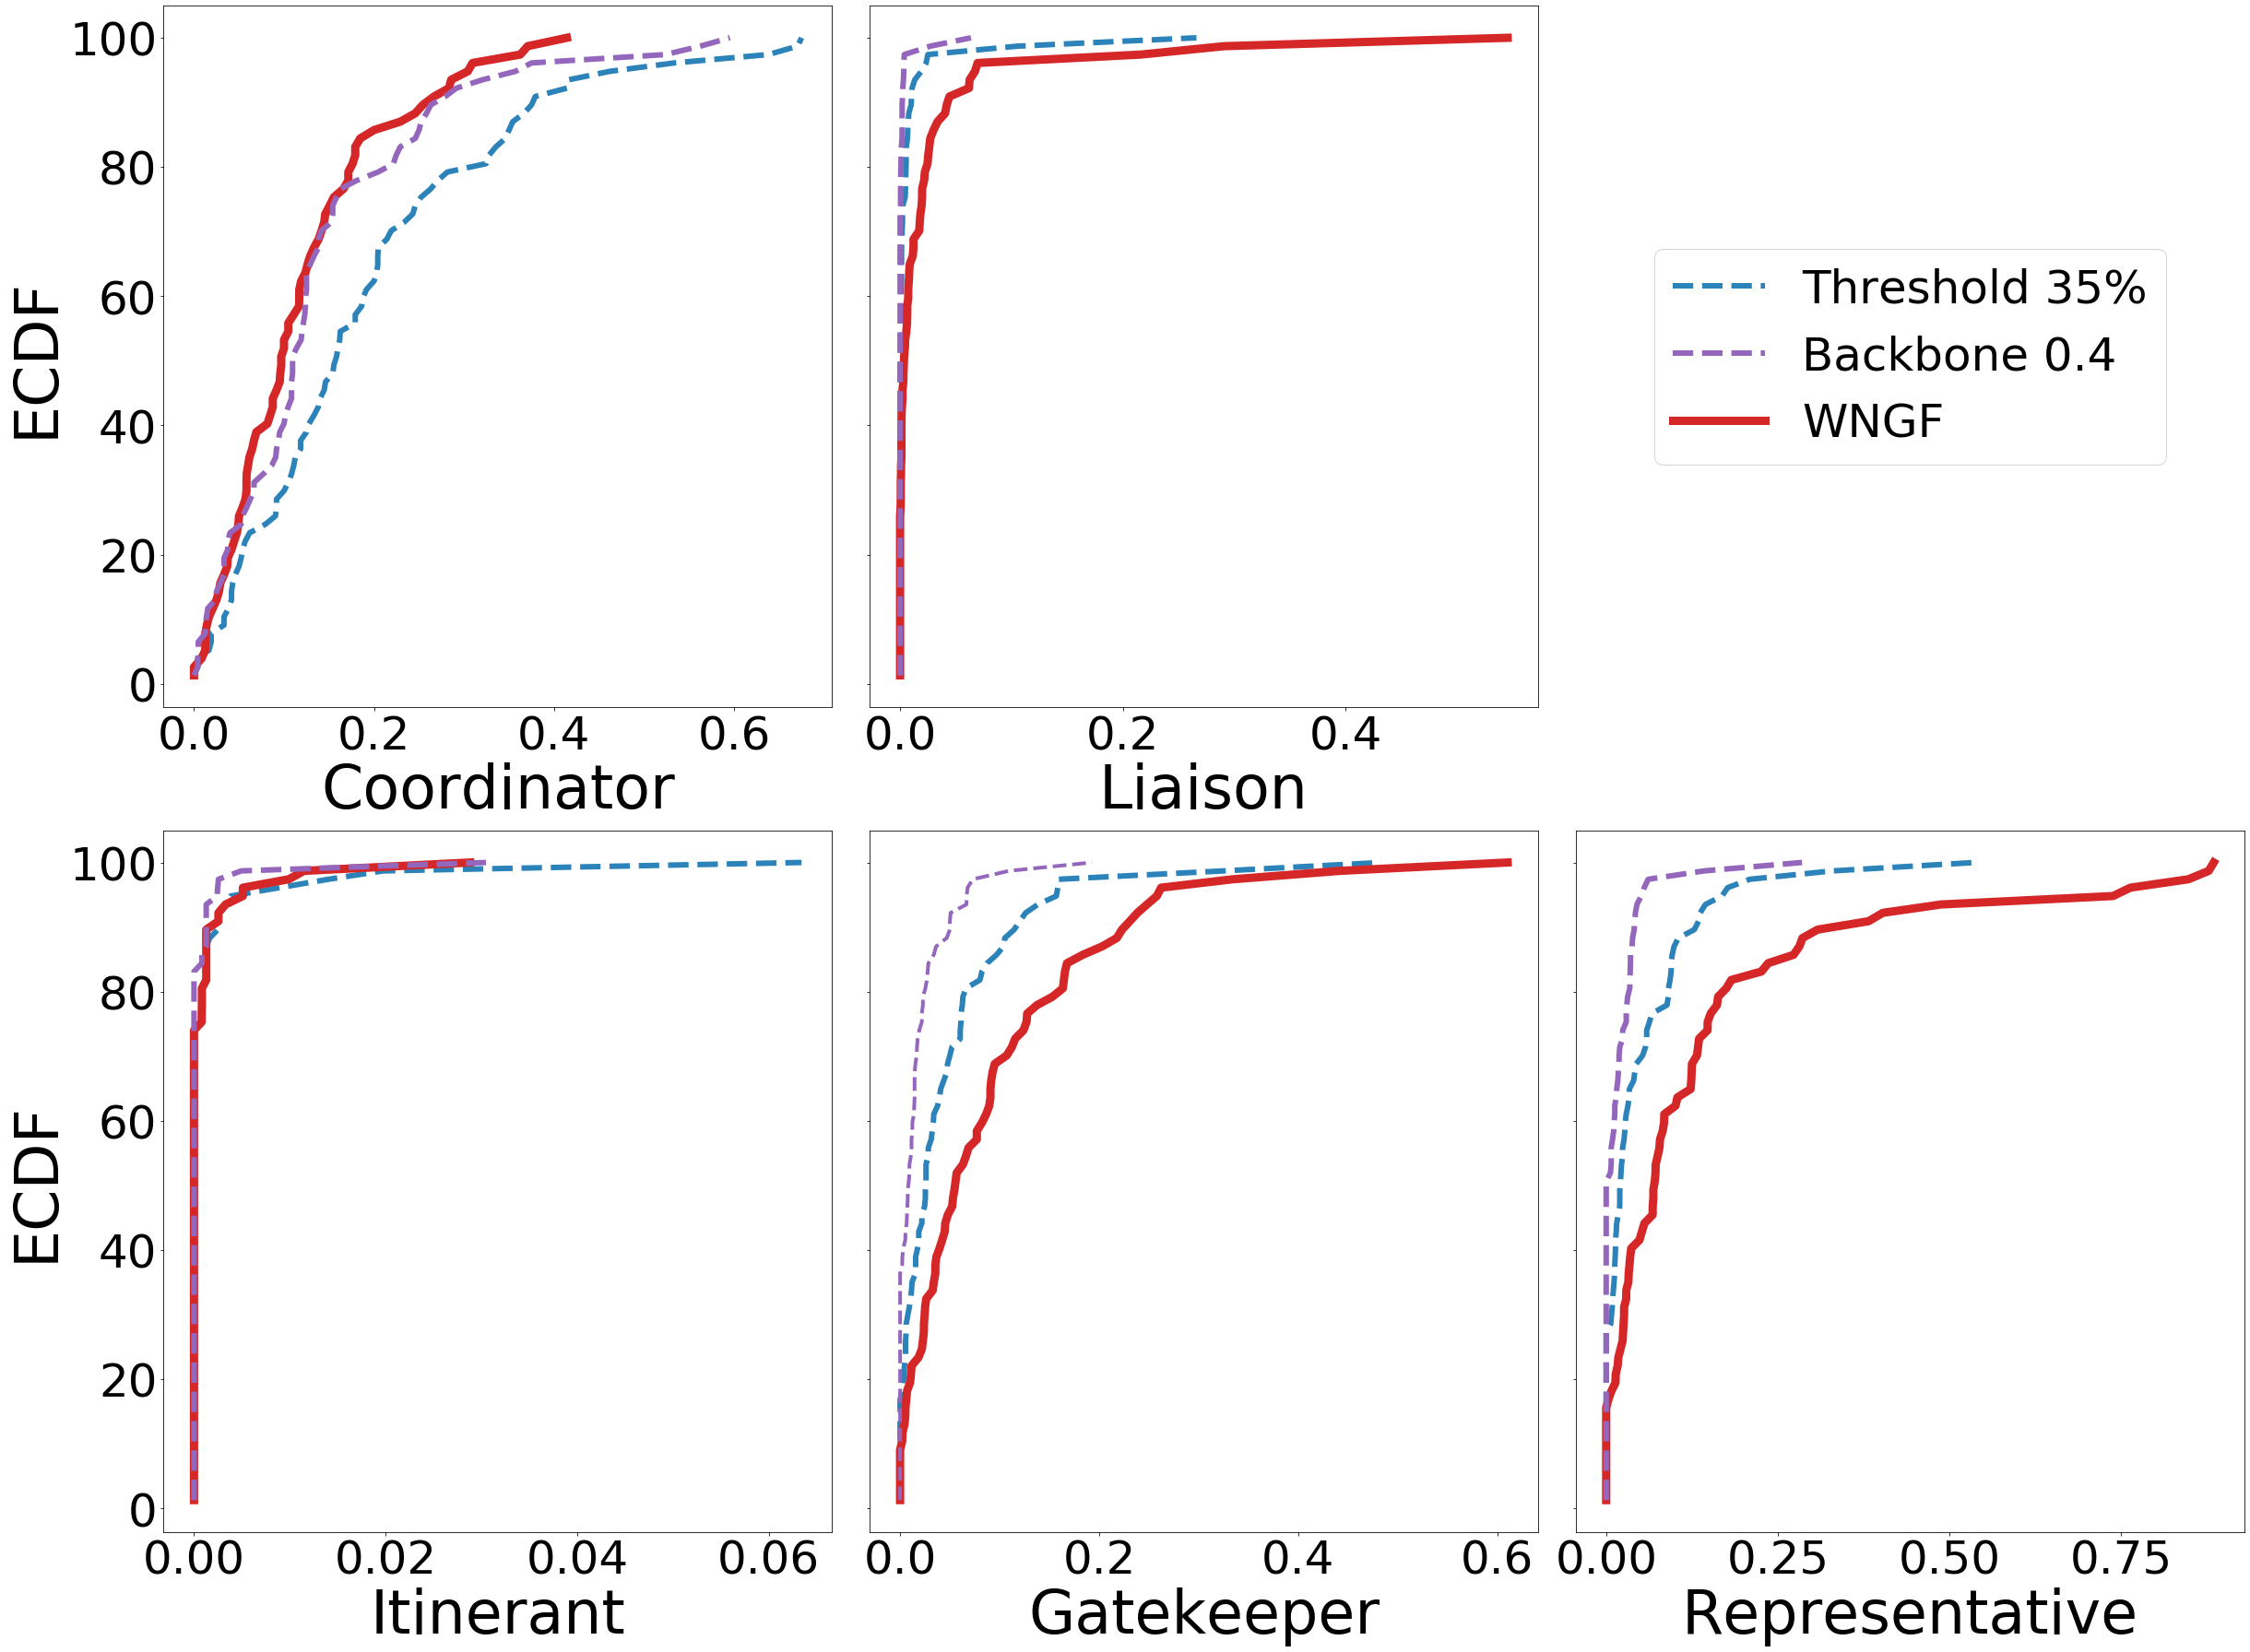

In [41]:
fig = plt.figure(figsize=(34,25))
#plt.subplots(2, 3, sharex='col', sharey='row')

x = [0.0, 1.0]
x2 = [0, 100]


sub1 = fig.add_subplot(2,3,1)
# Plot the ECDF as dots
_ = plt.plot(x_coord10, y_coord10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_coord20, y_coord20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_coord40, y_coord40*100, linestyle='--', lw = 4)
_ = plt.plot(x_coord, y_coord*100, linestyle='solid', lw = 9, color='C3')
_ = plt.plot(x_coordb, y_coordb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x2 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10%", "Threshold 20%", "Threshold 40%", "Backbone", "Weighted-Norm."), fontsize = 25, ncol= 1)
_ = plt.xlabel('Coordinator', fontdict={'fontsize': '65', 'fontweight' : '3'} )
_ = plt.ylabel('ECDF', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.tick_params(axis ='y', labelsize=50)
_ = plt.tick_params(axis= 'x', labelsize= 50)
#plt.tight_layout()
sub1.plot()

sub2 = fig.add_subplot(2,3,2)
# Plot the ECDF as dots
_ = plt.plot(x_liais10, y_liais10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_liais20, y_liais20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_liais40, y_liais40*100, linestyle='--', lw = 4)
_ = plt.plot(x_liais, y_liais*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_liaisb, y_liaisb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Liaison', fontdict={'fontsize': '65', 'fontweight' : '3'})

#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
#_ = plt.tick_params(axis= 'x', labelsize= 40)
sub2.plot()

lastSubplot = fig.add_subplot(2,3,3)
lastSubplot.set_frame_on(False)
lastSubplot.get_xaxis().set_visible(False)
lastSubplot.get_yaxis().set_visible(False)
plt.plot(0, 0, linestyle='--', lw = 6,color= "#2b83ba")
plt.plot(0, 0, linestyle='--', lw = 6, color='C4')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C2')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C4')
#plt.plot(0,0, linestyle=':', lw = 6, color = 'grey')
plt.plot(0, 0, linestyle='solid', lw = 9, color='C3')
lastSubplot.legend(("Threshold 35%", "Backbone 0.4", "WNGF"),
                   fontsize = 50, ncol= 1, loc= 'center')


sub3 = fig.add_subplot(2,3,4)
# Plot the ECDF as dots
_ = plt.plot(x_itin10, y_itin10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_itin20, y_itin20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_itin40, y_itin40*100, linestyle='--', lw = 4)
_ = plt.plot(x_itin, y_itin*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_itinb, y_itinb*100, linestyle='--', lw = 6,color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Itinerant', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.ylabel('ECDF', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.tick_params(axis ='both', labelsize=50)
#_ = plt.tick_params(axis='x',label1On=False)
sub3.plot()

sub4 = fig.add_subplot(2,3,5)
# Plot the ECDF as dots
_ = plt.plot(x_gate10, y_gate10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_gate20, y_gate20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_gate40, y_gate40*100, linestyle='--', lw = 4)
_ = plt.plot(x_gate, y_gate*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_gateb, y_gateb*100, linestyle='--', lw = 4, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10%", "Threshold 20%", "Threshold 40%", "Backbone", "Weighted-Norm."), fontsize = 28, ncol= 2)
_ = plt.xlabel('Gatekeeper', fontdict={'fontsize': '65', 'fontweight' : '3'})
#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
#_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
_ = plt.tick_params(axis='y',label1On=False)
#plt.tight_layout()
#plt.tight_layout()

sub5 = fig.add_subplot(2,3,6)
# Plot the ECDF as dots
_ = plt.plot(x_rep10, y_rep10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_rep20, y_rep20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_rep40, y_rep40*100, linestyle='--', lw = 4)
_ = plt.plot(x_rep, y_rep*100, linestyle='solid', lw = 9, color='C3')
_ = plt.plot(x_repb, y_repb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Representative', fontdict={'fontsize': '65', 'fontweight' : '3'} )
#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
sub5.plot()




#fig.suptitle('ECDF of Coordinator and Representative roles', fontsize = 65, fontweight = 3)
fig.tight_layout()


#plt.savefig('../figures/ECDF_manufact_comp_corr.png', dpi=400)

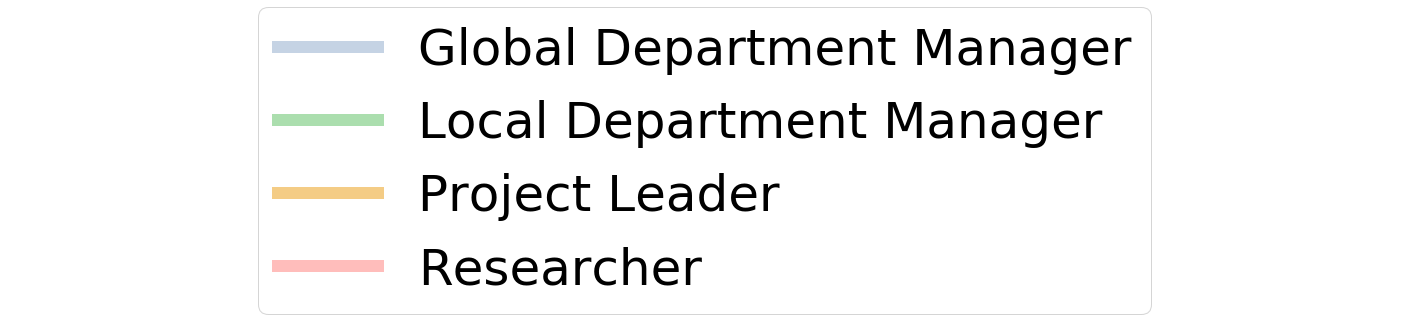

In [149]:
fig = plt. figure(figsize=(25,5))

lastSubplot = fig.add_subplot(1,1,1)
lastSubplot.set_frame_on(False)
lastSubplot.get_xaxis().set_visible(False)
lastSubplot.get_yaxis().set_visible(False)
plt.plot(0, 0, linestyle='-', lw = 12,color= "#C5D3E4")
plt.plot(0, 0, linestyle='-', lw = 12, color='#ABDEAE')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C2')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C4')
plt.plot(0,0, linestyle='-', lw = 12, color = '#F4CC85')
plt.plot(0, 0, linestyle='solid', lw = 12, color='#FFBDBB')
lastSubplot.legend(("Global Department Manager", "Local Department Manager", "Project Leader", "Researcher"),
                   fontsize = 50, ncol= 1, loc= 'center')
plt.savefig('../figures/network_legend.png')

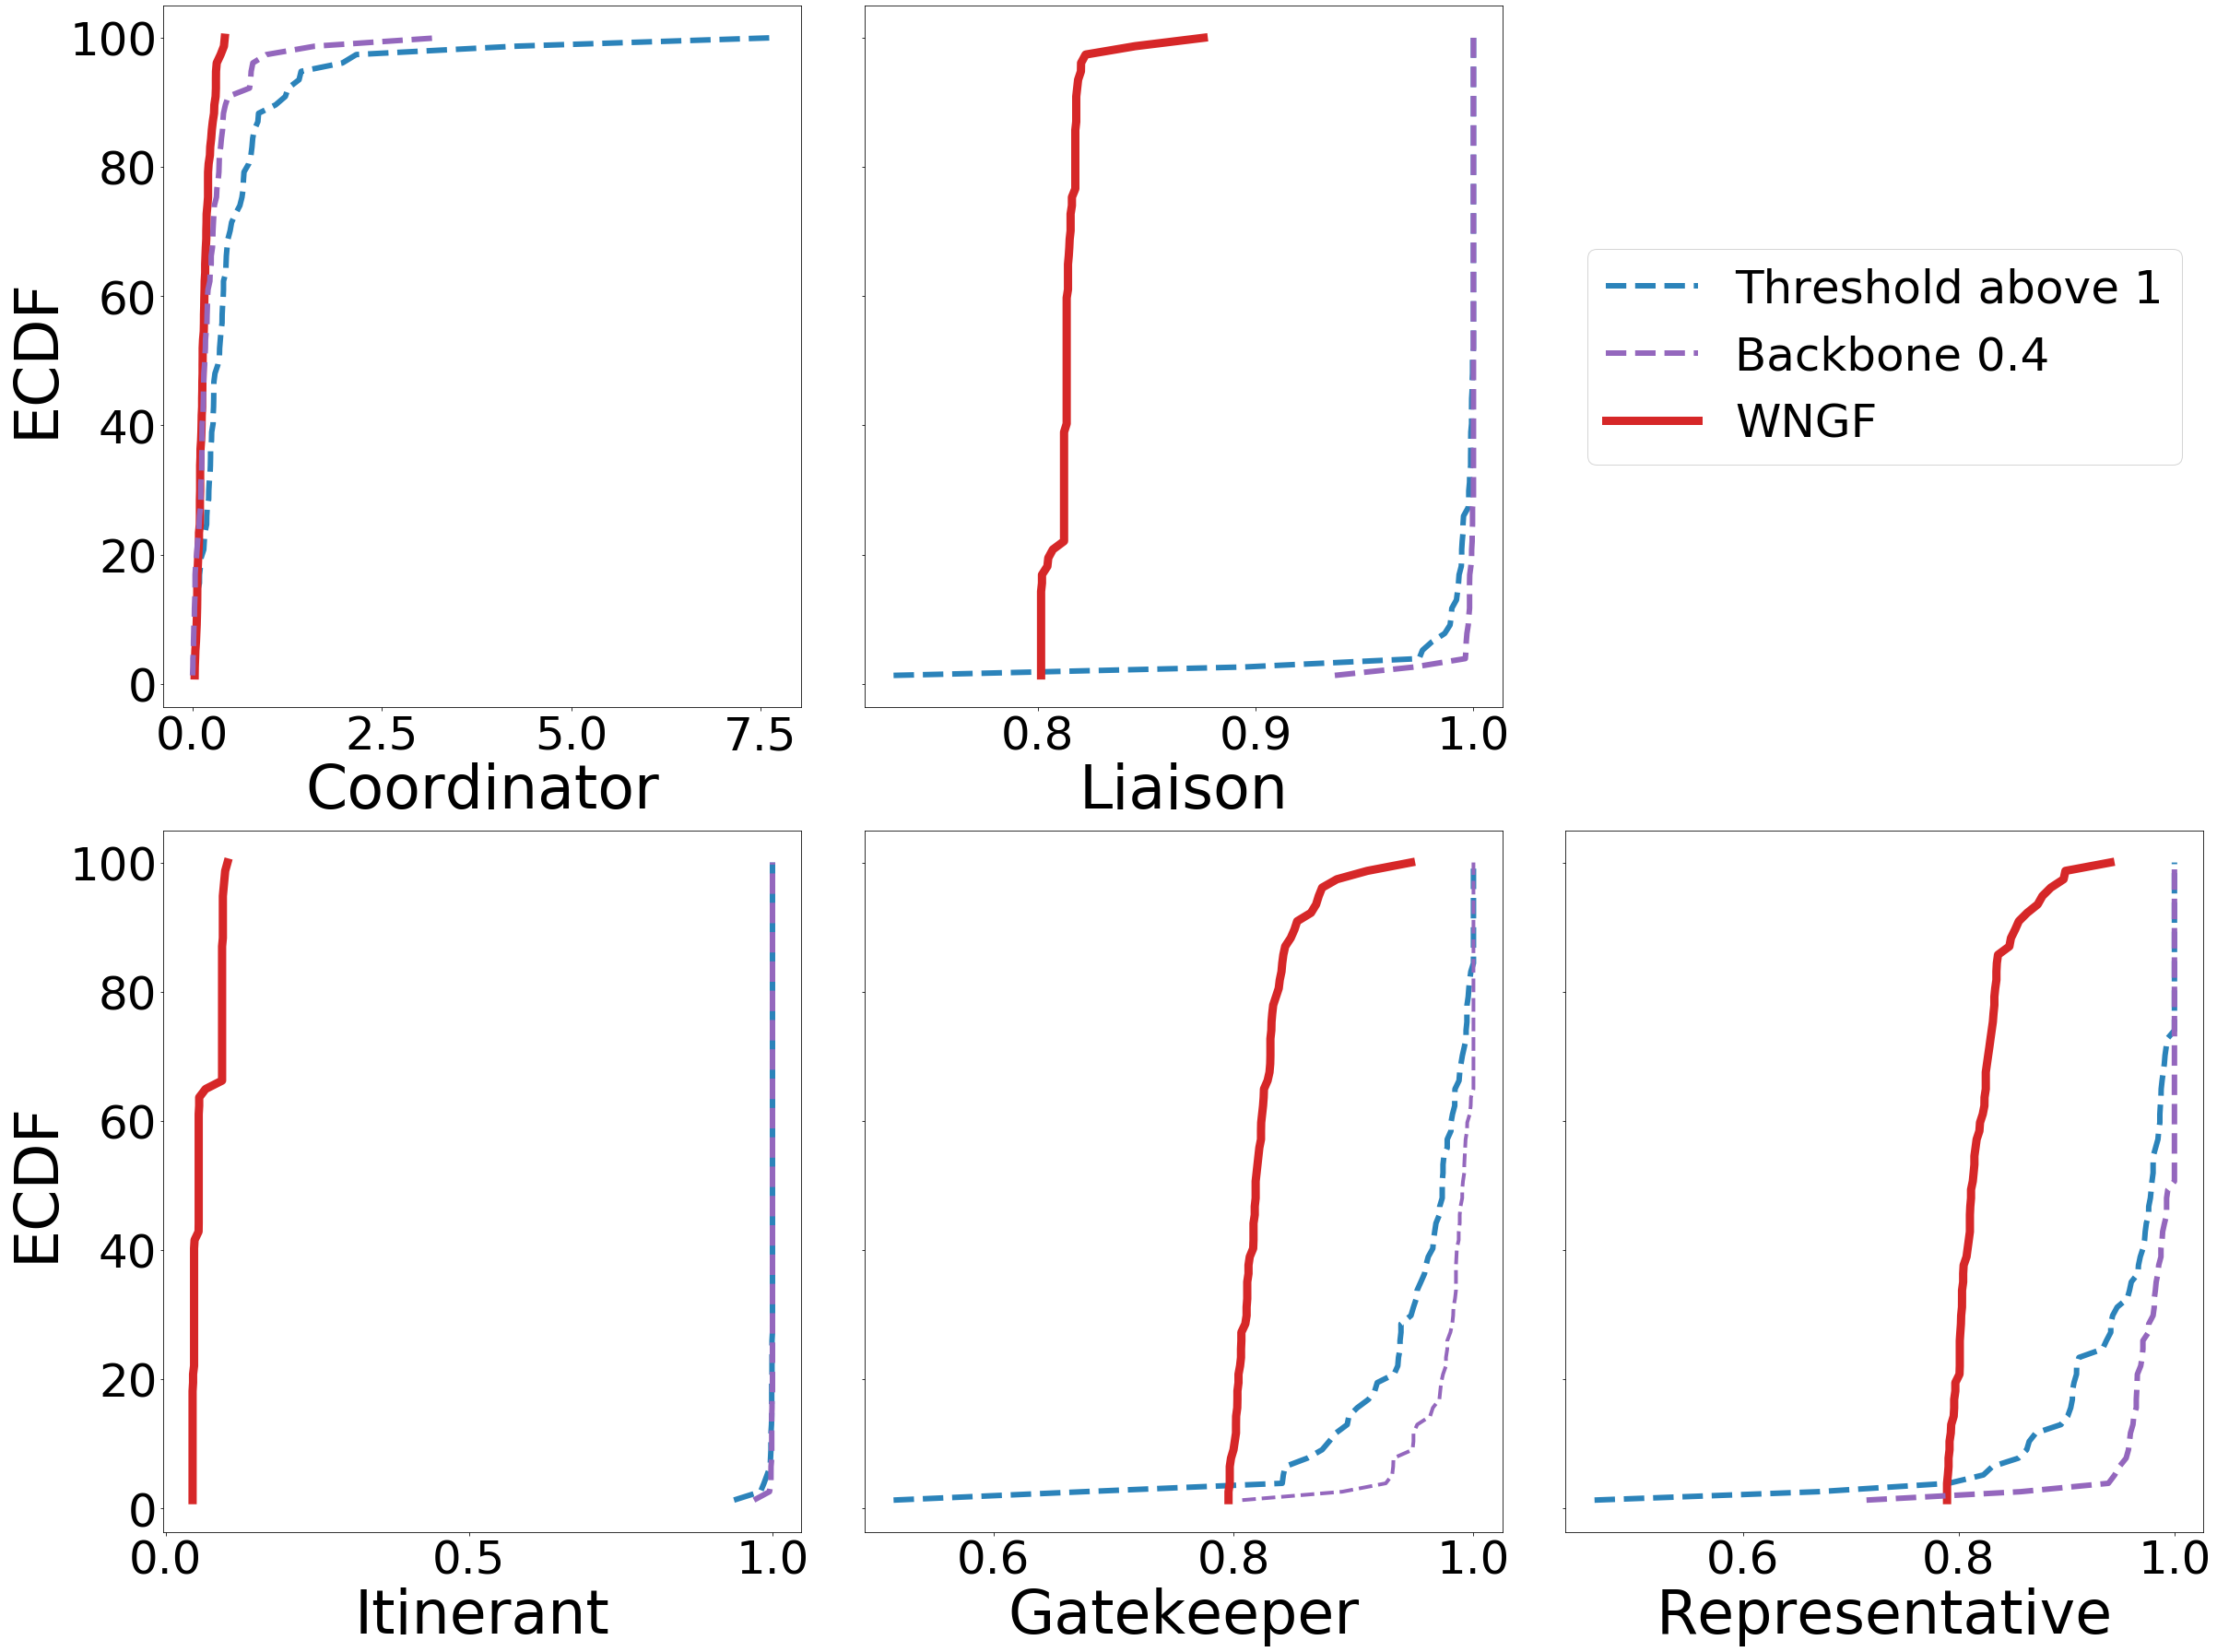

In [205]:
fig = plt.figure(figsize=(34,25))
#plt.subplots(2, 3, sharex='col', sharey='row')

x = [0.0, 1.0]
x2 = [0, 100]


sub1 = fig.add_subplot(2,3,1)
# Plot the ECDF as dots
_ = plt.plot(x_coord10, y_coord10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_coord20, y_coord20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_coord40, y_coord40*100, linestyle='--', lw = 4)
_ = plt.plot(x_coord, y_coord*100, linestyle='solid', lw = 9, color='C3')
_ = plt.plot(x_coordb, y_coordb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x2 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10%", "Threshold 20%", "Threshold 40%", "Backbone", "Weighted-Norm."), fontsize = 25, ncol= 1)
_ = plt.xlabel('Coordinator', fontdict={'fontsize': '65', 'fontweight' : '3'} )
_ = plt.ylabel('ECDF', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.tick_params(axis ='y', labelsize=50)
_ = plt.tick_params(axis= 'x', labelsize= 50)
#plt.tight_layout()
sub1.plot()

sub2 = fig.add_subplot(2,3,2)
# Plot the ECDF as dots
_ = plt.plot(x_liais10, y_liais10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_liais20, y_liais20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_liais40, y_liais40*100, linestyle='--', lw = 4)
_ = plt.plot(x_liais, y_liais*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_liaisb, y_liaisb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Liaison', fontdict={'fontsize': '65', 'fontweight' : '3'})

#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
#_ = plt.tick_params(axis= 'x', labelsize= 40)
sub2.plot()

lastSubplot = fig.add_subplot(2,3,3)
lastSubplot.set_frame_on(False)
lastSubplot.get_xaxis().set_visible(False)
lastSubplot.get_yaxis().set_visible(False)
plt.plot(0, 0, linestyle='--', lw = 6,color= "#2b83ba")
plt.plot(0, 0, linestyle='--', lw = 6, color='C4')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C2')
#plt.plot(0, 0, linestyle='--', lw = 4, color='C4')
#plt.plot(0,0, linestyle=':', lw = 6, color = 'grey')
plt.plot(0, 0, linestyle='solid', lw = 9, color='C3')
lastSubplot.legend(("Threshold above 1", "Backbone 0.4", "WNGF"),
                   fontsize = 50, ncol= 1, loc= 'center')


sub3 = fig.add_subplot(2,3,4)
# Plot the ECDF as dots
_ = plt.plot(x_itin10, y_itin10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_itin20, y_itin20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_itin40, y_itin40*100, linestyle='--', lw = 4)
_ = plt.plot(x_itin, y_itin*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_itinb, y_itinb*100, linestyle='--', lw = 6,color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Itinerant', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.ylabel('ECDF', fontdict={'fontsize': '65', 'fontweight' : '3'})
_ = plt.tick_params(axis ='both', labelsize=50)
#_ = plt.tick_params(axis='x',label1On=False)
sub3.plot()

sub4 = fig.add_subplot(2,3,5)
# Plot the ECDF as dots
_ = plt.plot(x_gate10, y_gate10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_gate20, y_gate20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_gate40, y_gate40*100, linestyle='--', lw = 4)
_ = plt.plot(x_gate, y_gate*100, linestyle='-', lw = 9, color='C3')
_ = plt.plot(x_gateb, y_gateb*100, linestyle='--', lw = 4, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10%", "Threshold 20%", "Threshold 40%", "Backbone", "Weighted-Norm."), fontsize = 28, ncol= 2)
_ = plt.xlabel('Gatekeeper', fontdict={'fontsize': '65', 'fontweight' : '3'})
#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
#_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
_ = plt.tick_params(axis='y',label1On=False)
#plt.tight_layout()
#plt.tight_layout()

sub5 = fig.add_subplot(2,3,6)
# Plot the ECDF as dots
_ = plt.plot(x_rep10, y_rep10*100, linestyle='--', lw = 6, color= "#2b83ba")
#_ = plt.plot(x_rep20, y_rep20*100, linestyle='--', lw = 4)
#_ = plt.plot(x_rep40, y_rep40*100, linestyle='--', lw = 4)
_ = plt.plot(x_rep, y_rep*100, linestyle='solid', lw = 9, color='C3')
_ = plt.plot(x_repb, y_repb*100, linestyle='--', lw = 6, color='C4')
#_ = plt.plot(x, x*100 , linestyle=':', lw = 6, color = 'grey')
# Label axes and show plot
#_ = plt.legend(("Threshold 10", "Threshold 20", "Threshold 40", "Backbone", "Normalized"))
_ = plt.xlabel('Representative', fontdict={'fontsize': '65', 'fontweight' : '3'} )
#_ = plt.ylabel('ECDF', fontdict={'fontsize': '55', 'fontweight' : '3'})
_ = plt.tick_params(axis='y',label1On=False)
_ = plt.tick_params(axis= 'x', labelsize= 50)
sub5.plot()




#fig.suptitle('ECDF of Coordinator and Representative roles', fontsize = 65, fontweight = 3)
fig.tight_layout()


#plt.savefig('../figures/ECDF_manufact_comp.png', dpi=400)

In [94]:
gf_freq['total2'] = gf_freq.coordinator + gf_freq.itinerant + gf_freq.gatekeeper + gf_freq.representative + gf_freq.liaison
gf_freq_b['total2'] = gf_freq_b.coordinator + gf_freq_b.itinerant + gf_freq_b.gatekeeper + gf_freq_b.representative + gf_freq_b.liaison
gf_freq_th['total2'] = gf_freq_th.coordinator + gf_freq_th.itinerant + gf_freq_th.gatekeeper + gf_freq_th.representative + gf_freq_th.liaison

(0.8726344154215303, 4.751393749248023e-25)


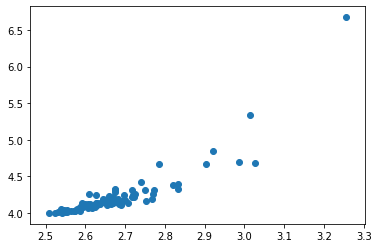

In [209]:
from scipy.stats import pearsonr
print(pearsonr(gf_freq.total2, gf_freq_b.total2))
plt.scatter(gf_freq.total2, gf_freq_b.total2)

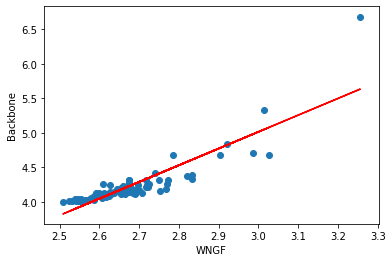

In [215]:
from sklearn.linear_model import LinearRegression

X = gf_freq.total2.values.reshape(-1, 1)  # values converts it into a numpy array
Y = gf_freq_b.total2.values.reshape(-1, 1)  # -1 means that calculate the dimension of rows, but have 1 column
linear_regressor = LinearRegression()  # create object for the class
linear_regressor.fit(X, Y)  # perform linear regression
Y_pred = linear_regressor.predict(X)  # make predictions
plt.scatter(X, Y)
plt.plot(X, Y_pred, color='red')
plt.xlabel('WNGF')
plt.ylabel('Backbone')
#plt.show()
plt.savefig('../figures/correlation.png')

# Network 

In [21]:
# create a network where there is no edge weight 0, instead the edge is missing
matrix_np = matrix.to_numpy()
G2 = nx.from_numpy_matrix(matrix_np, create_using=nx.DiGraph)
mapping = dict(zip(G2, attribute.index))
G2 = nx.relabel_nodes(G2, mapping)  

In [24]:
print(nx.info(G2))

Name: 
Type: DiGraph
Number of nodes: 77
Number of edges: 2228
Average in degree:  28.9351
Average out degree:  28.9351


C:\Users\zador.zsofia\AppData\Local\Continuum\anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
C:\Users\zador.zsofia\AppData\Local\Continuum\anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:676: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if cb.iterable(node_size):  # many node sizes


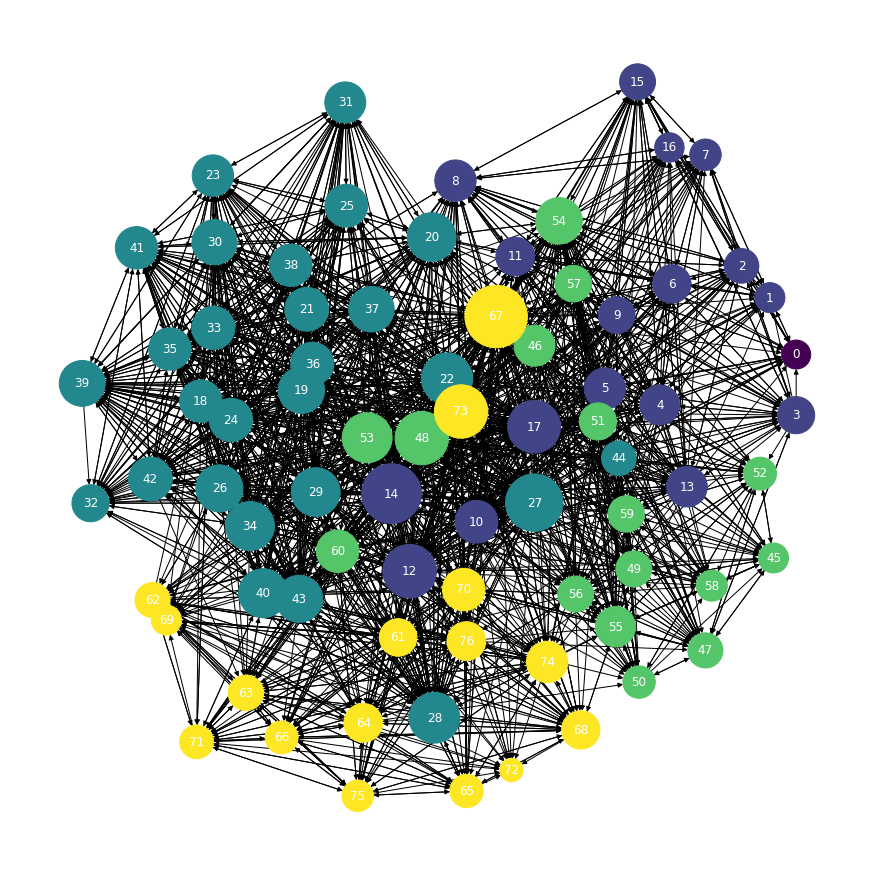

In [16]:
val_map = dict(zip(attribute.index, attribute.location))

#area_dict = dict(zip(lakes.area, lakes.count))

values = [val_map.get(node, 0.25) for node in G2.nodes()]
d = dict(G2.degree)
pos = nx.kamada_kawai_layout(G2)

#nx.draw(g, nodelist=d.keys(), node_size=[v * 100 for v in d.values()])

plt.figure(3,figsize=(12,12)) 
nx.draw(G2, pos, cmap=plt.get_cmap('viridis'), node_color=values, with_labels=True, font_color='white', node_size=[v * 30 for v in d.values()])
#fig.set_size_inches(8,6)
#(figsize=(8, 6), dpi=80)
plt.show()

# Scatterplots

In [92]:
coord = gf_freq.iloc[:, [0,1]]
coord['backb'] = gf_freq_b['coordinator']
coord['thresh'] = gf_freq_th['coordinator']

C:\Users\zador.zsofia\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\zador.zsofia\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [93]:
coord

,node,coordinator,backb,thresh
0,1,0.020833,0.033333,0.033333
1,2,0.037500,0.012500,0.041667
2,3,0.179167,0.245833,0.350000
3,4,0.058333,0.091667,0.112500
4,5,0.129167,0.125000,0.162500
...,...,...,...,...
72,73,0.000000,0.000000,0.000000
73,74,0.058333,0.125000,0.125000
74,75,0.245833,0.291667,0.375000
75,76,0.012500,0.033333,0.041667


In [86]:
gf_freq_b.head()

,node,coordinator,itinerant,gatekeeper,representative,liaison,total
0,1,0.033333,0.0,0.000000,0.000000,0.00000,8
1,2,0.012500,0.0,0.000000,0.000000,0.00000,3
2,3,0.245833,0.0,0.000000,0.000000,0.00000,59
3,4,0.091667,0.0,0.014583,0.034375,0.00000,69
4,5,0.125000,0.0,0.014583,0.018750,0.00043,63


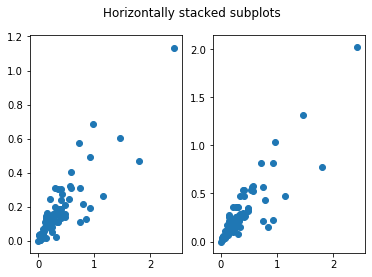

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Horizontally stacked subplots')
#plt.scatter(gf_freq.total2, gf_freq_b.total2)
ax1.scatter(gf_freq.total2, gf_freq_b.total2)
ax2.scatter(gf_freq.total2, gf_freq_th.total2)
#ax2.plot(x, -y)

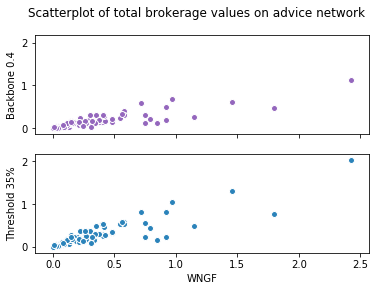

In [126]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, sharey=True)
fig.suptitle('Scatterplot of total brokerage values on advice network')
#plt.scatter(gf_freq.total2, gf_freq_b.total2)
ax1.scatter(gf_freq.total2, gf_freq_b.total2, color='C4', edgecolors= 'white')
#ax1.set_title("WNGF vs. backbone")
ax1.set_ylabel("Backbone 0.4")
ax2.scatter(gf_freq.total2, gf_freq_th.total2,  color= '#2b83ba', edgecolors= 'white')
#ax2.set_title("WNGF vs. threshold")
ax2.set_ylabel("Threshold 35%")
ax2.set_xlabel('WNGF')
#fig.savefig('../figures/correlation_robcross.png', dpi=400)


Text(0.5, 1.0, 'WNGF vs. threshold')

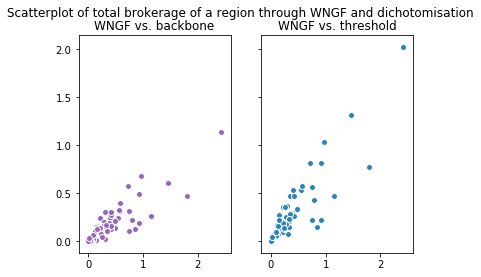

In [117]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)
fig.suptitle('Scatterplot of total brokerage of a region through WNGF and dichotomisation')
#plt.scatter(gf_freq.total2, gf_freq_b.total2)
ax1.scatter(gf_freq.total2, gf_freq_b.total2, color='C4', edgecolors= 'white')
ax1.set_title("WNGF vs. backbone")
ax2.scatter(gf_freq.total2, gf_freq_th.total2,  color= '#2b83ba', edgecolors= 'white')
ax2.set_title("WNGF vs. threshold")
